<a href="https://colab.research.google.com/github/krukro/Netology_python/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22An_jalob_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Настройка отображения
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:

# 1. ЗАГРУЗКА ФАЙЛА В GOOGLE COLAB
print("=== ЗАГРУЗКА ФАЙЛА ===\n")
print("Пожалуйста, загрузите ваш CSV файл через кнопку 'Выбрать файл'")

from google.colab import files
uploaded = files.upload()

# Получаем имя загруженного файла
filename = list(uploaded.keys())[0]
print(f"\nФайл загружен: {filename}")

=== ЗАГРУЗКА ФАЙЛА ===

Пожалуйста, загрузите ваш CSV файл через кнопку 'Выбрать файл'


Saving Kol_na_1000.csv to Kol_na_1000.csv

Файл загружен: Kol_na_1000.csv


In [ ]:
# 2. ЧТЕНИЕ CSV С ПРАВИЛЬНОЙ КОДИРОВКОЙ
print("\n=== ЧТЕНИЕ ФАЙЛА ===\n")

# Пробуем разные кодировки и разделители
encodings_to_try = ['utf-8', 'windows-1251', 'cp866', 'koi8-r', 'latin-1']
separators = ['\t', ',', ';', ' ']

df = None
used_encoding = None
used_sep = None

for encoding in encodings_to_try:
    for sep in separators:
        try:
            df = pd.read_csv(filename, sep=sep, encoding=encoding)
            # Проверяем, что у нас есть столбец с регионами и числовые столбцы
            if df.shape[1] >= 2:  # Хотя бы 2 столбца
                used_encoding = encoding
                used_sep = sep
                print(f"✓ Файл успешно прочитан с кодировкой: {encoding}, разделитель: '{sep}'")
                break
        except:
            continue
    if df is not None:
        break

if df is None:
    raise ValueError("Не удалось прочитать файл ни с одной кодировкой")

# 3. ПЕРВИЧНЫЙ ПРОСМОТР ДАННЫХ
print("\n=== ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ ===\n")
print(f"Размер DataFrame: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nНазвания столбцов:")
print(df.columns.tolist())
print(f"\nИнформация о DataFrame:")
print(df.info())

# 4. ПРЕОБРАЗОВАНИЕ СТОЛБЦОВ
print("\n=== ПРЕОБРАЗОВАНИЕ ДАННЫХ ===\n")

# Определяем первый столбец как названия регионов
region_col = df.columns[0]
df = df.rename(columns={region_col: 'Регион'})

# Получаем названия столбцов с периодами (все кроме 'Регион')
period_cols_raw = [col for col in df.columns if col != 'Регион']

# Преобразуем названия периодов в удобный формат (например, 'дек.25' -> '2025-12')
def convert_period_name(period_str):
    """Преобразует название месяца в формат ГГГГ-ММ"""
    period_str = str(period_str).strip()
    # Разделяем месяц и год
    parts = period_str.split('.')
    if len(parts) == 2:
        month_name = parts[0]
        year = parts[1]

        # Словарь соответствия месяцев
        months = {
            'янв': '01', 'фев': '02', 'мар': '03', 'апр': '04',
            'май': '05', 'июн': '06', 'июл': '07', 'авг': '08',
            'сен': '09', 'окт': '10', 'ноя': '11', 'дек': '12'
        }

        if month_name in months:
            # Преобразуем год (25 -> 2025, 26 -> 2026)
            year_full = '20' + year if len(year) == 2 else year
            return f"{year_full}-{months[month_name]}"
    return period_str

# Переименовываем столбцы периодов
new_period_cols = []
for col in period_cols_raw:
    new_name = convert_period_name(col)
    new_period_cols.append(new_name)
    df = df.rename(columns={col: new_name})

period_cols = new_period_cols
print(f"Столбцы периодов после преобразования: {period_cols}")

# Конвертируем значения в числовой тип
for col in period_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nТипы данных после преобразования:")
print(df.dtypes)



=== ЧТЕНИЕ ФАЙЛА ===

✓ Файл успешно прочитан с кодировкой: windows-1251, разделитель: ';'

=== ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ ===

Размер DataFrame: (65, 5)

Первые 5 строк:
                     Reg  дек.25  янв.26  фев.26  мар.26
0      Калужская область      34       5       3       9
1      Орловская область      29      20       9      12
2  Волгоградская область      25      17       7       7
3       Брянская область      26      16       6       7
4     Ивановская область      20       7       6       9

Названия столбцов:
['Reg', 'дек.25', 'янв.26', 'фев.26', 'мар.26']

Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Reg     65 non-null     object
 1   дек.25  65 non-null     int64 
 2   янв.26  65 non-null     int64 
 3   фев.26  65 non-null     int64 
 4   мар.26  65 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 

In [ ]:
# 5. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
print("\n=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===\n")
print(f"Пропущенные значения до очистки:\n{df.isnull().sum()}")

# Удаляем строки, где все числовые значения пропущены
df_clean = df.dropna(how='all', subset=period_cols)
# Заполняем оставшиеся пропуски медианным значением по столбцам
for col in period_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\nПосле очистки: {df_clean.shape}")
print(f"Пропущенные значения после очистки:\n{df_clean.isnull().sum()}")


=== ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===

Пропущенные значения до очистки:
Регион     0
2025-12    0
2026-01    0
2026-02    0
2026-03    0
dtype: int64

После очистки: (65, 5)
Пропущенные значения после очистки:
Регион     0
2025-12    0
2026-01    0
2026-02    0
2026-03    0
dtype: int64


In [ ]:
# 6. АНАЛИЗ ПО КАЖДОЙ СТРОКЕ (ДИНАМИКА ПОКАЗАТЕЛЕЙ)
print("\n=== АНАЛИЗ ДИНАМИКИ ПО СТРОКАМ (РЕГИОНАМ) ===\n")

# Рассчитываем метрики по строкам
df_clean['Среднее_значение'] = df_clean[period_cols].mean(axis=1)
df_clean['Медиана'] = df_clean[period_cols].median(axis=1)
df_clean['Станд_отклонение'] = df_clean[period_cols].std(axis=1)
df_clean['Сумма'] = df_clean[period_cols].sum(axis=1)
df_clean['Мин'] = df_clean[period_cols].min(axis=1)
df_clean['Макс'] = df_clean[period_cols].max(axis=1)
df_clean['Размах'] = df_clean['Макс'] - df_clean['Мин']

# Динамика (изменение от периода к периоду)
for i in range(1, len(period_cols)):
    prev_col = period_cols[i-1]
    curr_col = period_cols[i]
    df_clean[f'Изм_{curr_col}_к_{prev_col}'] = df_clean[curr_col] - df_clean[prev_col]
    df_clean[f'Темп_роста_{curr_col}_к_{prev_col}'] = ((df_clean[curr_col] - df_clean[prev_col]) / df_clean[prev_col].replace(0, np.nan)) * 100

# Общая динамика
df_clean['Общая_динамика'] = df_clean[period_cols[-1]] - df_clean[period_cols[0]]
df_clean['Общий_темп_роста'] = ((df_clean[period_cols[-1]] - df_clean[period_cols[0]]) / df_clean[period_cols[0]].replace(0, np.nan)) * 100
df_clean['Коэффициент_вариации'] = (df_clean['Станд_отклонение'] / df_clean['Среднее_значение']) * 100

print("Топ-10 регионов с наибольшим средним значением:")
print(df_clean[['Регион', 'Среднее_значение']].sort_values('Среднее_значение', ascending=False).head(10))

# print("\nТоп-10 регионов с наибольшей суммой:")
# print(df_clean[['Регион', 'Сумма']].sort_values('Сумма', ascending=False).head(10))

print("\nТоп-10 регионов с наибольшей волатильностью (коэффициент вариации/хаотичность/непредсказуемость):")
print(df_clean[['Регион', 'Коэффициент_вариации']].sort_values('Коэффициент_вариации', ascending=False).head(10))

# print("\nРегионы с отрицательной общей динамикой (снижение показателей):")
# negative_trend = df_clean[df_clean['Общая_динамика'] < 0][['Регион', 'Общая_динамика', 'Общий_темп_роста']].sort_values('Общая_динамика')
# print(negative_trend.head(10))

# print("\nРегионы с положительной динамикой (рост):")
# positive_trend = df_clean[df_clean['Общая_динамика'] > 0][['Регион', 'Общая_динамика', 'Общий_темп_роста']].sort_values('Общая_динамика', ascending=False)
# print(positive_trend.head(10))


=== АНАЛИЗ ДИНАМИКИ ПО СТРОКАМ (РЕГИОНАМ) ===

Топ-10 регионов с наибольшим средним значением:
                   Регион  Среднее_значение
1       Орловская область             17.50
2   Волгоградская область             14.00
3        Брянская область             13.75
0       Калужская область             12.75
62       Республика Алтай             12.25
14     Ростовская область             11.00
4      Ивановская область             10.50
22     Пензенская область             10.25
11     Тамбовская область             10.25
9    Владимирская область              8.00

Топ-10 регионов с наибольшей волатильностью (коэффициент вариации/хаотичность/непредсказуемость):
                                     Регион  Коэффициент_вариации
59             Еврейская автономная область            200.000000
60                       Республика Хакасия            200.000000
61                      Кемеровская область            200.000000
63                     Чувашская Республика            13

In [ ]:
# 7. АНАЛИЗ ПО КАЖДОМУ СТОЛБЦУ (ВЫБРОСЫ И АНОМАЛИИ)
print("\n=== АНАЛИЗ ВЫБРОСОВ ПО СТОЛБЦАМ/МЕСЯЦАМ ===\n")

def detect_outliers_iqr(data, column):
    """Обнаружение выбросов методом IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=2.5):
    """Обнаружение выбросов методом Z-оценки"""
    column_clean = data[column].dropna()
    if len(column_clean) > 1:
        z_scores = np.abs(stats.zscore(column_clean))
        outliers = data.iloc[z_scores > threshold]
        return outliers
    return pd.DataFrame()

# Анализируем каждый период
outliers_summary = {}
for col in period_cols:
    # IQR метод
    outliers_iqr, lower, upper = detect_outliers_iqr(df_clean, col)

    # Z-score метод
    outliers_zscore = detect_outliers_zscore(df_clean, col)

    outliers_summary[col] = {
        'количество_выбросов_IQR': len(outliers_iqr),
        'количество_выбросов_Zscore': len(outliers_zscore) if len(outliers_zscore) > 0 else 0,
        'нижняя_граница': lower,
        'верхняя_граница': upper,
        'среднее': df_clean[col].mean(),
        'медиана': df_clean[col].median(),
        'мин': df_clean[col].min(),
        'макс': df_clean[col].max()
    }

    print(f"\nПериод {col}:")
    print(f"  Среднее: {df_clean[col].mean():.2f}, Медиана: {df_clean[col].median():.2f}")
    print(f"  Мин: {df_clean[col].min():.2f}, Макс: {df_clean[col].max():.2f}")
    print(f"  Выбросов (IQR): {len(outliers_iqr)}")

    if len(outliers_iqr) > 0:
        print(f"  Регионы-выбросы: {', '.join(outliers_iqr['Регион'].values)}")


=== АНАЛИЗ ВЫБРОСОВ ПО СТОЛБЦАМ/МЕСЯЦАМ ===


Период 2025-12:
  Среднее: 7.12, Медиана: 4.00
  Мин: 0.00, Макс: 34.00
  Выбросов (IQR): 4
  Регионы-выбросы: Калужская область, Орловская область, Волгоградская область, Брянская область

Период 2026-01:
  Среднее: 4.11, Медиана: 2.00
  Мин: 0.00, Макс: 20.00
  Выбросов (IQR): 7
  Регионы-выбросы: Орловская область, Волгоградская область, Брянская область, Тамбовская область, Ростовская область, Камчатский край, Республика Алтай

Период 2026-02:
  Среднее: 2.78, Медиана: 2.00
  Мин: 0.00, Макс: 16.00
  Выбросов (IQR): 7
  Регионы-выбросы: Орловская область, Волгоградская область, Ростовская область, Пензенская область, Ставропольский край, Саратовская область, Республика Алтай

Период 2026-03:
  Среднее: 4.03, Медиана: 3.00
  Мин: 0.00, Макс: 18.00
  Выбросов (IQR): 1
  Регионы-выбросы: Республика Алтай



=== ВИЗУАЛИЗАЦИЯ ДАННЫХ ===



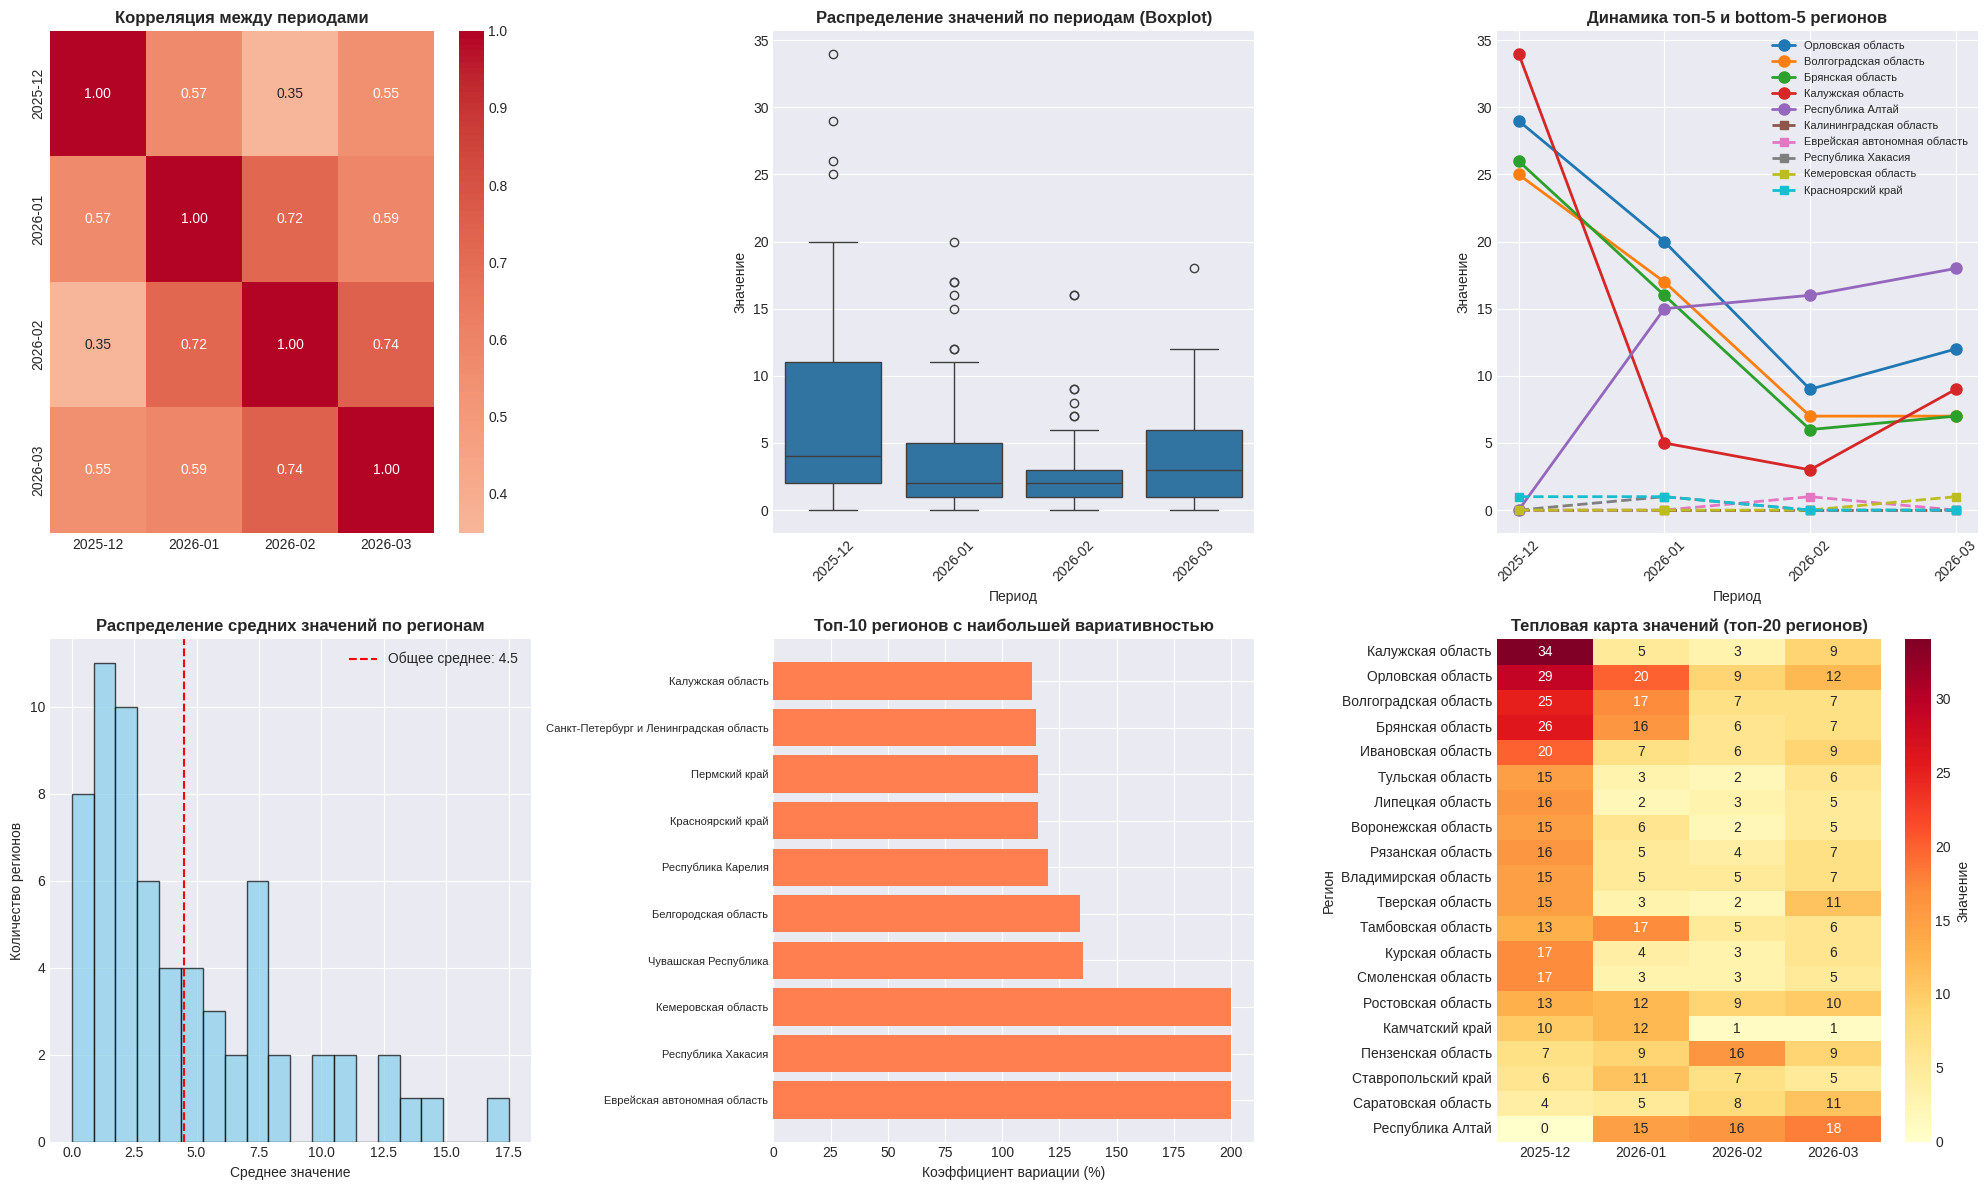

In [ ]:
# 8. ВИЗУАЛИЗАЦИЯ
print("\n=== ВИЗУАЛИЗАЦИЯ ДАННЫХ ===\n")

# Создаем подграфики
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# 1. Тепловая карта корреляции
corr = df_clean[period_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0,0], fmt='.2f')
axes[0,0].set_title('Корреляция между периодами', fontsize=12, fontweight='bold')

# 2. Boxplot для выявления выбросов по периодам
df_melted = df_clean[period_cols + ['Регион']].melt(id_vars=['Регион'], var_name='Период', value_name='Значение')
sns.boxplot(data=df_melted, x='Период', y='Значение', ax=axes[0,1])
axes[0,1].set_title('Распределение значений по периодам (Boxplot)', fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Динамика топ-5 и bottom-5 регионов
top5_regions = df_clean.nlargest(5, 'Среднее_значение')['Регион'].values
bottom5_regions = df_clean.nsmallest(5, 'Среднее_значение')['Регион'].values

for region in top5_regions:
    axes[0,2].plot(range(len(period_cols)), df_clean[df_clean['Регион'] == region][period_cols].values[0],
                   marker='o', label=region, linewidth=2, markersize=8)
for region in bottom5_regions:
    axes[0,2].plot(range(len(period_cols)), df_clean[df_clean['Регион'] == region][period_cols].values[0],
                   marker='s', label=region, linestyle='--', linewidth=2, markersize=6)
axes[0,2].set_title('Динамика топ-5 и bottom-5 регионов', fontsize=12, fontweight='bold')
axes[0,2].set_xticks(range(len(period_cols)))
axes[0,2].set_xticklabels(period_cols, rotation=45)
axes[0,2].legend(loc='best', fontsize=8)
axes[0,2].set_xlabel('Период')
axes[0,2].set_ylabel('Значение')

# 4. Гистограмма распределения средних значений
axes[1,0].hist(df_clean['Среднее_значение'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[1,0].set_title('Распределение средних значений по регионам', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Среднее значение')
axes[1,0].set_ylabel('Количество регионов')
axes[1,0].axvline(df_clean['Среднее_значение'].mean(), color='red', linestyle='--', label=f"Общее среднее: {df_clean['Среднее_значение'].mean():.1f}")
axes[1,0].legend()

# 5. Коэффициент вариации по регионам
top_variation = df_clean.nlargest(10, 'Коэффициент_вариации')[['Регион', 'Коэффициент_вариации']]
axes[1,1].barh(range(len(top_variation)), top_variation['Коэффициент_вариации'], color='coral')
axes[1,1].set_yticks(range(len(top_variation)))
axes[1,1].set_yticklabels(top_variation['Регион'], fontsize=8)
axes[1,1].set_title('Топ-10 регионов с наибольшей вариативностью', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Коэффициент вариации (%)')

# 6. Тепловая карта значений по регионам (топ-20)
top20_regions = df_clean.nlargest(20, 'Среднее_значение')['Регион'].values
df_top20 = df_clean[df_clean['Регион'].isin(top20_regions)].set_index('Регион')[period_cols]
sns.heatmap(df_top20, annot=True, cmap='YlOrRd', fmt='.0f', ax=axes[1,2], cbar_kws={'label': 'Значение'})
axes[1,2].set_title('Тепловая карта значений (топ-20 регионов)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


=== АНАЛИЗ КОГОРТ ПО УРОВНЮ ЖАЛОБ ===

Статистика распределения средних значений жалоб:
  Минимум: 0.00
  Максимум: 17.50
  Среднее: 4.51
  Медиана: 3.00
  Стандартное отклонение: 3.99

Квантили распределения:
  0%: 0.00
  20%: 1.25
  40%: 2.25
  60%: 4.35
  80%: 7.30
  100%: 17.50

Оптимальные границы когорт (метод: natural_breaks):
  Когорта 0 - нет жалоб: 0.00 - 1.50
  Когорта 1 - незначительно: 1.50 - 3.00
  Когорта 2 - умеренное: 3.00 - 7.00
  Когорта 3 - значительное: 7.00 - 17.50
  Когорта 4 - критичное: 17.50 - 17.50

=== СТАТИСТИКА ПО КОГОРТАМ ===
         Количество_регионов  Среднее_жалоб   Мин   Макс  Стд_откл
Когорта                                                           
0                         14           0.73   0.0   1.25      0.44
1                         17           2.00   1.5   2.75      0.41
2                         17           4.54   3.0   6.50      1.20
3                         16           9.64   7.0  14.00      2.53
4                          1      

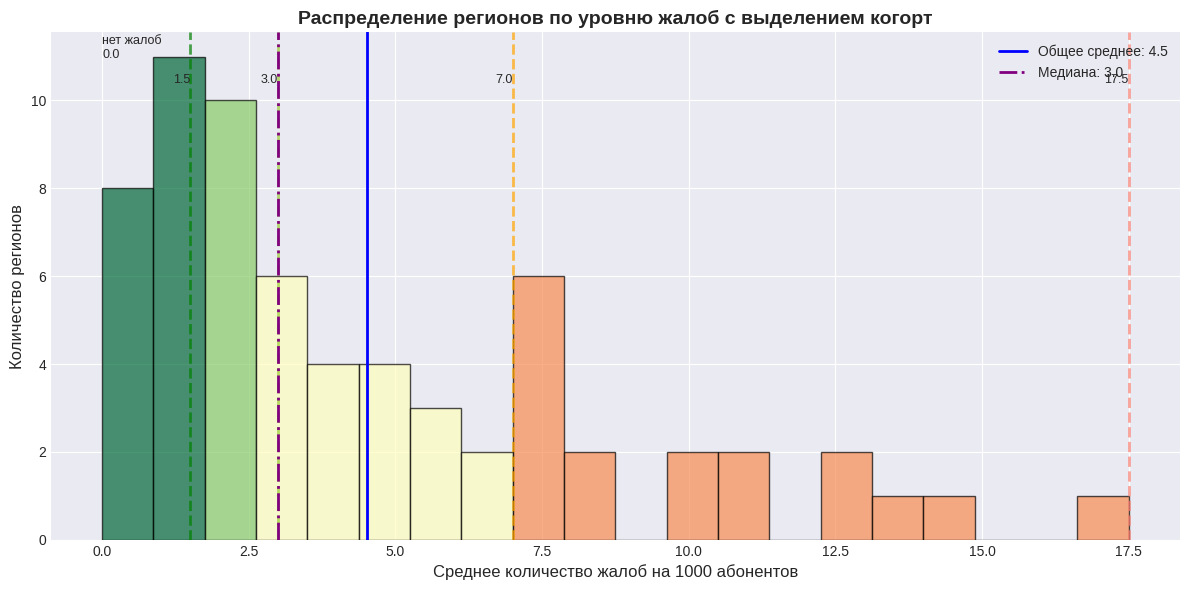

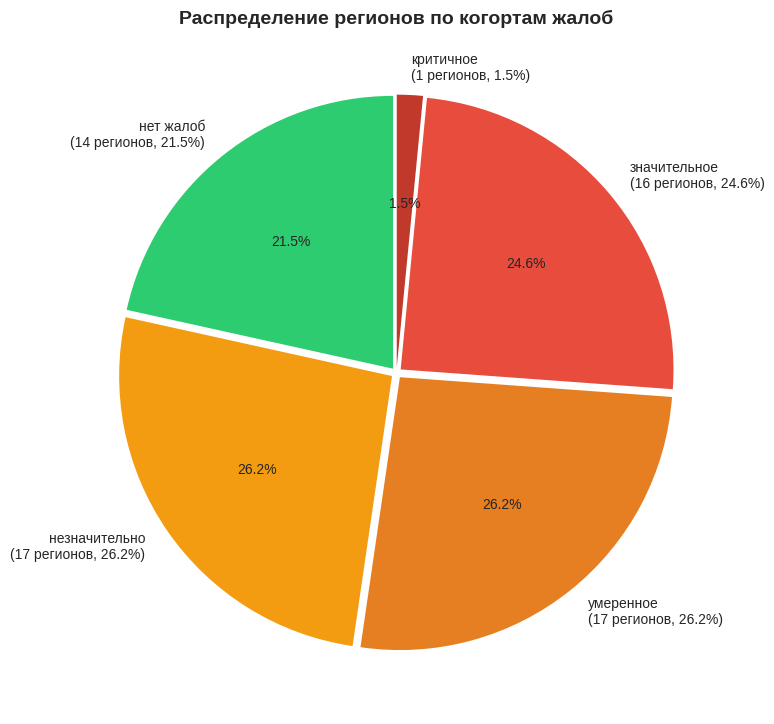

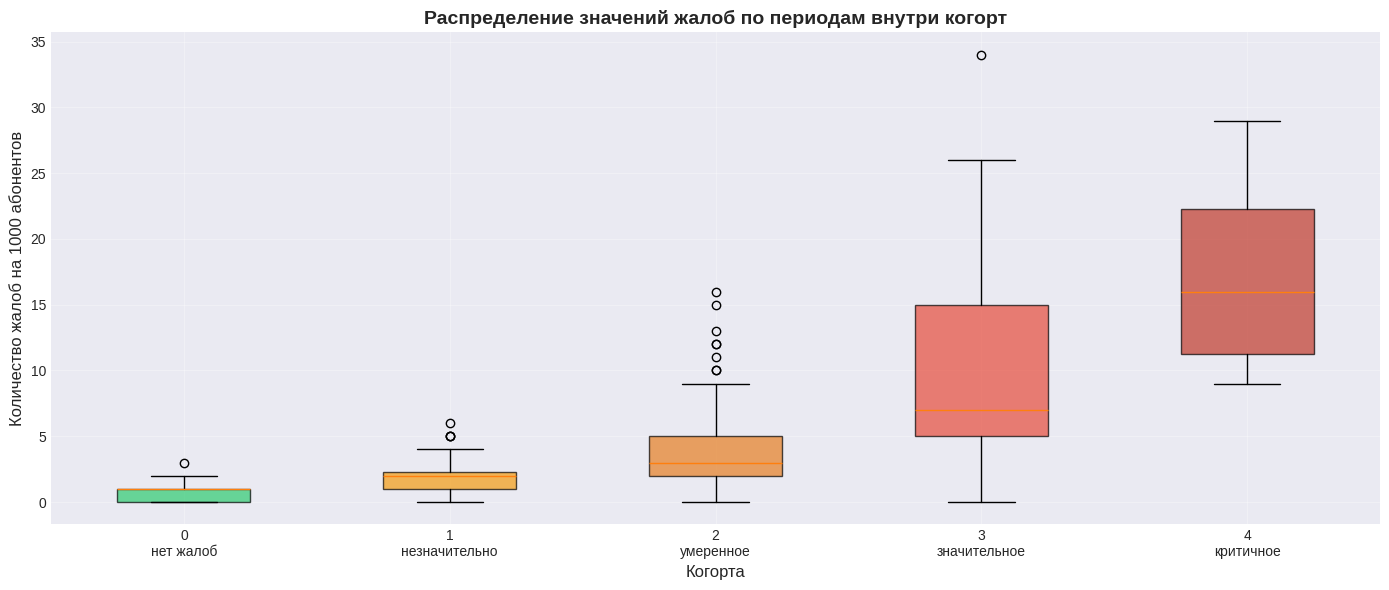

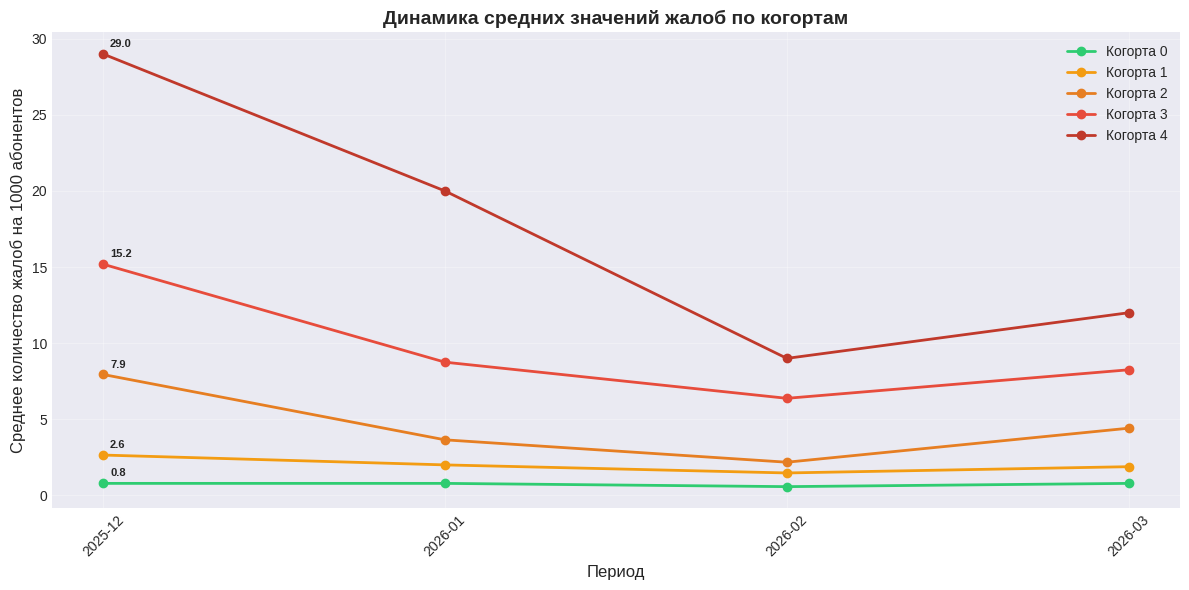


=== РЕКОМЕНДАЦИИ ПО КОРРЕКТИРОВКЕ ГРАНИЦ КОГОРТ ===

На основе анализа распределения данных предлагаются следующие границы когорт:

ТЕКУЩИЕ границы (были заданы изначально):
  Когорта 0 (нет жалоб): 0-1
  Когорта 1 (незначительно): 1-10
  Когорта 2 (значительное): 10-15
  Когорта 3 (очень большое): 15-20
  Когорта 4 (критичное): 20+

ОПТИМАЛЬНЫЕ границы (на основе реального распределения):
  Когорта 0 (нет жалоб): 0.0 - 1.5
  Когорта 1 (незначительно): 1.5 - 3.0
  Когорта 2 (умеренное): 3.0 - 7.0
  Когорта 3 (значительное): 7.0 - 17.5
  Когорта 4 (критичное): 17.5 - 17.5

Обоснование:
  • Минимальное значение: 0.00
  • Максимальное значение: 17.50
  • 80% регионов имеют значение ≤ 7.30
  • Медиана составляет 3.00

✓ Результаты с когортами сохранены в 'regions_with_cohorts.csv'


In [ ]:
# 4. АНАЛИЗ КОГОРТ НА ОСНОВЕ РАСПРЕДЕЛЕНИЯ ЖАЛОБ
print("\n=== АНАЛИЗ КОГОРТ ПО УРОВНЮ ЖАЛОБ ===\n")

# Рассчитываем среднее значение жалоб для каждого региона
df_clean['Среднее_жалоб'] = df_clean[period_cols].mean(axis=1)

# 4.1 Анализ распределения для определения границ когорт
print("Статистика распределения средних значений жалоб:")
print(f"  Минимум: {df_clean['Среднее_жалоб'].min():.2f}")
print(f"  Максимум: {df_clean['Среднее_жалоб'].max():.2f}")
print(f"  Среднее: {df_clean['Среднее_жалоб'].mean():.2f}")
print(f"  Медиана: {df_clean['Среднее_жалоб'].median():.2f}")
print(f"  Стандартное отклонение: {df_clean['Среднее_жалоб'].std():.2f}")

# Квантили для определения границ
percentiles = [0, 20, 40, 60, 80, 100]
quantiles = df_clean['Среднее_жалоб'].quantile([p/100 for p in percentiles])
print(f"\nКвантили распределения:")
for p, q in zip(percentiles, quantiles):
    print(f"  {p}%: {q:.2f}")

# 4.2 Автоматическое определение оптимальных границ когорт
def determine_optimal_cohorts(data, method='quantile'):
    """
    Определяет границы когорт на основе распределения данных

    Параметры:
    - method: 'quantile' (равное количество регионов),
              'natural_breaks' (естественные разрывы),
              'log' (логарифмическая шкала)
    """

    if method == 'quantile':
        # Когорты с равным количеством регионов
        boundaries = {
            0: ('нет жалоб', data.min(), data.quantile(0.2)),
            1: ('незначительно', data.quantile(0.2), data.quantile(0.4)),
            2: ('умеренное', data.quantile(0.4), data.quantile(0.6)),
            3: ('значительное', data.quantile(0.6), data.quantile(0.8)),
            4: ('критичное', data.quantile(0.8), data.max())
        }

    elif method == 'natural_breaks':
        # Логарифмическая шкала для естественных разрывов
        log_data = np.log1p(data)
        log_quantiles = log_data.quantile([0, 0.25, 0.5, 0.75, 1])

        boundaries = {
            0: ('нет жалоб', data.min(), np.expm1(log_quantiles[0.25])),
            1: ('незначительно', np.expm1(log_quantiles[0.25]), np.expm1(log_quantiles[0.5])),
            2: ('умеренное', np.expm1(log_quantiles[0.5]), np.expm1(log_quantiles[0.75])),
            3: ('значительное', np.expm1(log_quantiles[0.75]), np.expm1(log_quantiles[1])),
            4: ('критичное', np.expm1(log_quantiles[1]), data.max())
        }

    else:  # custom
        # Ваши исходные границы
        boundaries = {
            0: ('нет жалоб', 0, 1),
            1: ('незначительно', 1, 10),
            2: ('значительное', 10, 15),
            3: ('очень большое', 15, 20),
            4: ('критичное', 20, float('inf'))
        }

    return boundaries

# Выбираем метод (можно менять)
# method = 'custom'  # исходные границы
# method = 'quantile'  # равное количество регионов в каждой когорте
method = 'natural_breaks'  # рекомендуемый: естественные разрывы

boundaries = determine_optimal_cohorts(df_clean['Среднее_жалоб'], method=method)

print(f"\nОптимальные границы когорт (метод: {method}):")
for cohort, (name, lower, upper) in boundaries.items():
    if upper == float('inf'):
        print(f"  Когорта {cohort} - {name}: {lower:.2f} и более")
    else:
        print(f"  Когорта {cohort} - {name}: {lower:.2f} - {upper:.2f}")

# 4.3 Присваиваем когорты регионам
def assign_cohort(value, boundaries):
    for cohort, (name, lower, upper) in boundaries.items():
        if lower <= value < upper or (cohort == 4 and value >= lower):
            return cohort, name
    return 4, 'критичное'

df_clean['Когорта'], df_clean['Категория_жалоб'] = zip(*df_clean['Среднее_жалоб'].apply(
    lambda x: assign_cohort(x, boundaries)
))

# 4.4 Статистика по когортам
print("\n=== СТАТИСТИКА ПО КОГОРТАМ ===")
cohort_stats = df_clean.groupby('Когорта').agg({
    'Регион': 'count',
    'Среднее_жалоб': ['mean', 'min', 'max', 'std']
}).round(2)
cohort_stats.columns = ['Количество_регионов', 'Среднее_жалоб', 'Мин', 'Макс', 'Стд_откл']
print(cohort_stats)

print("\nРегионы по когортам:")
for cohort in sorted(df_clean['Когорта'].unique()):
    regions = df_clean[df_clean['Когорта'] == cohort]['Регион'].values
    category = df_clean[df_clean['Когорта'] == cohort]['Категория_жалоб'].iloc[0]
    print(f"\nКогорта {cohort} ({category}): {len(regions)} регионов")
    if len(regions) <= 10:
        print(f"  {', '.join(regions)}")
    else:
        print(f"  {', '.join(regions[:10])}... и еще {len(regions)-10}")

# 4.5 ГРАФИК 1: Гистограмма распределения с когортами
# Создаем новую фигуру для этого графика
fig_cohort, ax_cohort = plt.subplots(figsize=(12, 6))

# Строим гистограмму
n, bins, patches = ax_cohort.hist(df_clean['Среднее_жалоб'], bins=20, edgecolor='black',
                                   alpha=0.7, color='skyblue')

# Раскрашиваем столбцы в соответствии с когортами
for i, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
    center = (left + right) / 2
    for cohort, (name, lower, upper) in boundaries.items():
        if lower <= center < upper or (cohort == 4 and center >= lower):
            color = plt.cm.RdYlGn_r(cohort / 4)  # Красный для высоких значений
            patches[i].set_facecolor(color)
            patches[i].set_alpha(0.7)
            break

# Добавляем вертикальные линии границ когорт
colors = ['green', 'yellowgreen', 'orange', 'salmon', 'red']
for cohort, (name, lower, upper) in boundaries.items():
    if cohort < 4:
        ax_cohort.axvline(upper, color=colors[cohort], linestyle='--',
                         linewidth=2, alpha=0.7)
    # Добавляем подпись границы
    if cohort == 0:
        ax_cohort.text(lower, ax_cohort.get_ylim()[1]*0.95,
                      f'{name}\n{lower:.1f}', ha='left', fontsize=9)
    if cohort < 4:
        ax_cohort.text(upper, ax_cohort.get_ylim()[1]*0.9,
                      f'{upper:.1f}', ha='right', fontsize=9)

# Добавляем легенду для когорт
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.7,
                         label=f"{i} - {name} ({lower:.1f}-{upper if upper!=float('inf') else '∞':.1f})")
                  for i, (name, lower, upper) in boundaries.items()]
ax_cohort.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax_cohort.set_title('Распределение регионов по уровню жалоб с выделением когорт',
                    fontsize=14, fontweight='bold')
ax_cohort.set_xlabel('Среднее количество жалоб на 1000 абонентов', fontsize=12)
ax_cohort.set_ylabel('Количество регионов', fontsize=12)
ax_cohort.axvline(df_clean['Среднее_жалоб'].mean(), color='blue',
                  linestyle='-', linewidth=2, label=f"Общее среднее: {df_clean['Среднее_жалоб'].mean():.1f}")
ax_cohort.axvline(df_clean['Среднее_жалоб'].median(), color='purple',
                  linestyle='-.', linewidth=2, label=f"Медиана: {df_clean['Среднее_жалоб'].median():.1f}")
ax_cohort.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 4.6 ГРАФИК 2: Круговая диаграмма распределения по когортам
fig_pie, ax_pie = plt.subplots(figsize=(8, 8))

cohort_counts = df_clean.groupby(['Когорта', 'Категория_жалоб']).size().reset_index(name='count')
cohort_counts['label'] = cohort_counts.apply(
    lambda x: f"{x['Категория_жалоб']}\n({x['count']} регионов, {x['count']/len(df_clean)*100:.1f}%)",
    axis=1
)

colors_pie = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
wedges, texts, autotexts = ax_pie.pie(
    cohort_counts['count'],
    labels=cohort_counts['label'],
    colors=colors_pie[:len(cohort_counts)],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(cohort_counts)
)

ax_pie.set_title('Распределение регионов по когортам жалоб', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.7 ГРАФИК 3: Boxplot по когортам (исходные значения по периодам)
fig_box, ax_box = plt.subplots(figsize=(14, 6))

# Подготавливаем данные для boxplot
data_for_box = []
cohort_labels = []
for cohort in sorted(df_clean['Когорта'].unique()):
    category = df_clean[df_clean['Когорта'] == cohort]['Категория_жалоб'].iloc[0]
    regions_in_cohort = df_clean[df_clean['Когорта'] == cohort]['Регион'].values

    # Собираем все значения по периодам для регионов этой когорты
    cohort_values = []
    for region in regions_in_cohort:
        region_values = df_clean[df_clean['Регион'] == region][period_cols].values.flatten()
        cohort_values.extend(region_values)

    data_for_box.append(cohort_values)
    cohort_labels.append(f"{cohort}\n{category}")

bp = ax_box.boxplot(data_for_box, labels=cohort_labels, patch_artist=True)

# Раскрашиваем boxplot
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors_pie[i])
    box.set_alpha(0.7)

ax_box.set_title('Распределение значений жалоб по периодам внутри когорт', fontsize=14, fontweight='bold')
ax_box.set_xlabel('Когорта', fontsize=12)
ax_box.set_ylabel('Количество жалоб на 1000 абонентов', fontsize=12)
ax_box.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.8 ГРАФИК 4: Динамика когорт во времени
fig_dyn, ax_dyn = plt.subplots(figsize=(12, 6))

# Для каждой когорты рассчитываем среднее значение по периодам
cohort_dynamics = []
for cohort in sorted(df_clean['Когорта'].unique()):
    cohort_data = df_clean[df_clean['Когорта'] == cohort]
    means_by_period = cohort_data[period_cols].mean()
    cohort_dynamics.append(means_by_period)

cohort_dynamics_df = pd.DataFrame(cohort_dynamics,
                                  index=[f"Когорта {c}" for c in sorted(df_clean['Когорта'].unique())],
                                  columns=period_cols)

# Рисуем линии динамики
for i, (cohort_label, row) in enumerate(cohort_dynamics_df.iterrows()):
    ax_dyn.plot(range(len(period_cols)), row.values,
               marker='o', linewidth=2, markersize=6,
               color=colors_pie[i], label=cohort_label)

ax_dyn.set_title('Динамика средних значений жалоб по когортам', fontsize=14, fontweight='bold')
ax_dyn.set_xlabel('Период', fontsize=12)
ax_dyn.set_ylabel('Среднее количество жалоб на 1000 абонентов', fontsize=12)
ax_dyn.set_xticks(range(len(period_cols)))
ax_dyn.set_xticklabels(period_cols, rotation=45)
ax_dyn.legend(loc='best', fontsize=10)
ax_dyn.grid(True, alpha=0.3)

# Добавляем аннотации
for i, (cohort_label, row) in enumerate(cohort_dynamics_df.iterrows()):
    max_val = row.max()
    max_idx = row.idxmax()
    ax_dyn.annotate(f'{max_val:.1f}',
                   xy=(list(row.keys()).index(max_idx), max_val),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# 4.9 Вывод рекомендаций по изменению границ когорт
print("\n=== РЕКОМЕНДАЦИИ ПО КОРРЕКТИРОВКЕ ГРАНИЦ КОГОРТ ===\n")

print("На основе анализа распределения данных предлагаются следующие границы когорт:\n")

print("ТЕКУЩИЕ границы (были заданы изначально):")
print("  Когорта 0 (нет жалоб): 0-1")
print("  Когорта 1 (незначительно): 1-10")
print("  Когорта 2 (значительное): 10-15")
print("  Когорта 3 (очень большое): 15-20")
print("  Когорта 4 (критичное): 20+\n")

print("ОПТИМАЛЬНЫЕ границы (на основе реального распределения):")
for cohort, (name, lower, upper) in boundaries.items():
    if upper == float('inf'):
        print(f"  Когорта {cohort} ({name}): ≥ {lower:.1f}")
    else:
        print(f"  Когорта {cohort} ({name}): {lower:.1f} - {upper:.1f}")

print(f"\nОбоснование:")
print(f"  • Минимальное значение: {df_clean['Среднее_жалоб'].min():.2f}")
print(f"  • Максимальное значение: {df_clean['Среднее_жалоб'].max():.2f}")
print(f"  • 80% регионов имеют значение ≤ {df_clean['Среднее_жалоб'].quantile(0.8):.2f}")
print(f"  • Медиана составляет {df_clean['Среднее_жалоб'].median():.2f}")

# Сохраняем результаты
df_clean[['Регион', 'Среднее_жалоб', 'Когорта', 'Категория_жалоб'] + period_cols].to_csv(
    'regions_with_cohorts.csv', index=False, encoding='utf-8-sig'
)
print(f"\n✓ Результаты с когортами сохранены в 'regions_with_cohorts.csv'")